In [10]:
import numpy as np
import pandas as pd
import sys
import os
import glob
import matplotlib.pyplot as plt
cwd = os.getcwd()
root = cwd.split("BernsteinMartingaleNet")[0] + "BernsteinMartingaleNet"
if root not in sys.path:
    sys.path.append(root)

In [14]:
names = []
train_losses = []
dev_losses = []
test_losses = []
for paths in glob.glob(root + "/Results/DistCompare/*"):
    names.append("paper " + paths.split("/")[-1])
    losses = pd.read_csv(paths + "/final_losses.csv")
    train_losses.append(losses.iloc[0]["loss"])
    dev_losses.append(losses.iloc[1]["loss"])
    test_losses.append(losses.iloc[2]["loss"])

for paths in glob.glob(root + "/Results/AdjustDistCompare/*"):
    names.append("adjust " + paths.split("/")[-1])
    losses = pd.read_csv(paths + "/final_losses.csv")
    train_losses.append(losses.iloc[0]["loss"])
    dev_losses.append(losses.iloc[1]["loss"])
    test_losses.append(losses.iloc[2]["loss"])


train_losses = np.array(train_losses)
dev_losses = np.array(dev_losses)
test_losses = np.array(test_losses)
baseline = 1.033497
mult = 100
#train_losses = mult * (train_losses - baseline)
#dev_losses = mult * (dev_losses - baseline)
#test_losses = mult * (test_losses - baseline)


In [15]:
df = pd.DataFrame({"name": names, "train_loss": train_losses, "dev_loss": dev_losses, "test_loss": test_losses}).set_index("name")

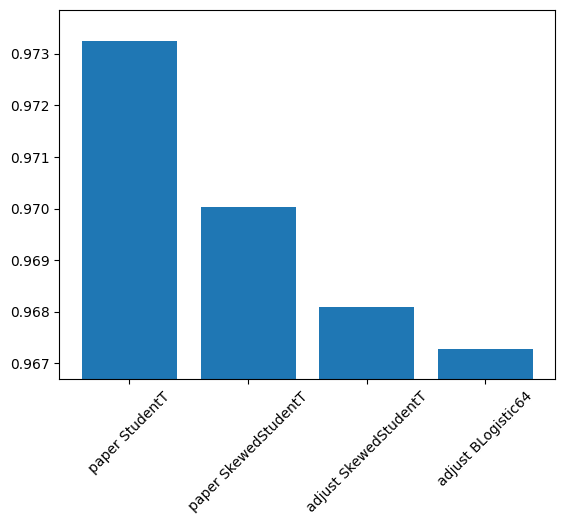

In [25]:
names = ["paper StudentT", "paper SkewedStudentT", "adjust SkewedStudentT", "adjust BLogistic64"]
values = df.loc[names, "test_loss"]
plt.bar(names, values)
scale = np.max(values) - np.min(values)
plt.ylim(np.min(values) - scale * 0.1, np.max(values) + scale * 0.1)
plt.xticks(rotation=45)
plt.show()